In [10]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional
from langchain_groq import ChatGroq
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
model = ChatGroq(model="openai/gpt-oss-20b")

class BlogState(BaseModel):
    title: str

    # ekhane optional dileo amake input e nnone value deya lagbei, so agei none set kora
    outline: Optional[str] = None
    content: Optional[str] = None

In [18]:
def create_outline(state: BlogState) -> BlogState:
    title = state.title
    prompt = f"Generate a detailed outline for a blog on the topic: {title}"
    response = model.invoke(prompt)
    state.outline = response.content

    return state

In [19]:
def create_blog(state: BlogState) -> BlogState:
    title = state.title
    outline = state.outline

    prompt = f"Geneare a detailed blog of title {title} and follow the outline {outline}"

    response = model.invoke(prompt)
    state.content = response.content

    return state

In [20]:
graph = StateGraph(BlogState)

# nnnodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

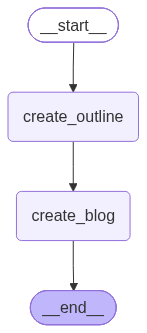

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [23]:
initial_state = {
    "title": "Who is the creator of Python?"
}

final_state = workflow.invoke(initial_state)
print(final_state["content"]) 

# Who Is the Creator of Python?  
*A Deep Dive Into Guido van Rossum and the Birth of a Programming Language*

---

## 1. Hook & Overview  

> “Python is a language that encourages good programming habits.” – *Guido van Rossum*  

When you think of a language that powers everything from the latest AI models to the backend of the world’s biggest websites, you might picture a slick, modern framework. In reality, its roots run deep—back to a Dutch mathematician’s curiosity, a 1980s teaching language, and a Monty Python sketch that became a cultural touchstone.

Python’s ubiquity today—data science, web development, automation, and even embedded systems—makes the question of *who actually created it* more than a trivia item. It’s a story of vision, community, and the evolution of a “Benevolent Dictator For Life” into a global stewardship model.  

In this post we’ll trace Guido van Rossum’s journey from a child in The Hague to the man who first typed the interpreter that would become the w